# PROJECT: AI for Sustainable Cities (SDG 11)

# THEME: Machine Learning Meets the UN Sustainable Development Goals

# Author: George Wanjohi

# OBJECTIVE: Clustering Urban Indicators for Sustainable Cities (SDG 11)

# 1. Imports and sets up libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import plotly.express as px
import folium
from folium.plugins import MarkerCluster

# Set visualization styles
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

## 2. Data Loading
Loading the UN DESA Population Division data files.

In [2]:
# Data Loading (assuming files are in 'data/' directory)
file_path_urban_agglomeration = 'data/WUP2018-DataSource-UrbanAgglomeration-and-CapitalCities.xls'
file_path_urban_population = 'data/WUP2018-DataSource-UrbanPopulation.xls'
file_path_locations = 'data/WUP2018-F00-LOCATIONS.xlsx'

# Initialize dataframes
df_urban_agglomeration = pd.DataFrame()
df_urban_population = pd.DataFrame()
df_locations = pd.DataFrame()

try:
    df_urban_agglomeration = pd.read_excel(file_path_urban_agglomeration, sheet_name='Data', skiprows=16, header=0)
    df_urban_agglomeration.rename(columns={'Location name': 'Urban Agglomeration'}, inplace=True)
    df_urban_agglomeration.dropna(subset=['Urban Agglomeration'], inplace=True)
    df_urban_agglomeration['Country Code'] = df_urban_agglomeration['Country Code'].astype(str)
    print("\n--- Urban Agglomeration Data ---")
    print(df_urban_agglomeration.info())
    print(df_urban_agglomeration.head())
except Exception as e:
    print(f"Error reading {file_path_urban_agglomeration}: {e}")
    df_urban_agglomeration = pd.DataFrame() # Ensure df is a DataFrame even on error

try:
    df_urban_population = pd.read_excel(file_path_urban_population, sheet_name='Data', skiprows=16, header=0)
    df_urban_population.rename(columns={'Data': 'Urban Population'}, inplace=True) # Assuming 'Data' is the urban population value
    # No 'Urban Agglomeration' in this file, so no dropna on it
    df_urban_population['Country Code'] = df_urban_population['Country Code'].astype(str)
    print("\n--- Urban Population Data ---")
    print(df_urban_population.info())
    print(df_urban_population.columns)
    print(df_urban_population.head())
except Exception as e:
    print(f"Error reading {file_path_urban_population}: {e}")
    df_urban_population = pd.DataFrame() # Ensure df is a DataFrame even on error

try:
    df_locations = pd.read_excel(file_path_locations, sheet_name='Location', skiprows=16, header=0)
    df_locations.rename(columns={'Region, subregion, country or area': 'Country Code', 'Name': 'City'}, inplace=True)
    df_locations.dropna(subset=['City'], inplace=True)
    df_locations['Country Code'] = df_locations['Country Code'].astype(str)
    print("\n--- Locations Data ---")
    print(df_locations.info())
    print(df_locations.columns)
    print(df_locations.head())
except Exception as e:
    print(f"Error reading {file_path_locations}: {e}")
    df_locations = pd.DataFrame() # Ensure df is a DataFrame even on error

# Revised Merge logic
df_combined = pd.DataFrame()
if not df_urban_agglomeration.empty and not df_locations.empty:
    # Merge urban agglomeration data with location data
    df_combined = pd.merge(df_urban_agglomeration, df_locations, 
                           left_on=['Country Code', 'Urban Agglomeration'], 
                           right_on=['Country Code', 'City'], 
                           how='left', suffixes=('_agg', '_loc'))
    if 'City' in df_combined.columns:
        df_combined.drop(columns=['City'], inplace=True)
else:
    print("Could not merge urban agglomeration and location data. Check source files.")

df = pd.DataFrame() # Initialize df to an empty DataFrame
if not df_combined.empty and not df_urban_population.empty:
    # Merge with urban population data at country level
    df = pd.merge(df_combined, df_urban_population[['Country Code', 'Urban Population']], 
                  on='Country Code', how='left')
elif not df_combined.empty:
    df = df_combined.copy() # If urban population data is missing, proceed with what's available
else:
    print("No data could be loaded or merged to create the final DataFrame 'df'.")

# Handle missing values (example: drop rows with too many NaNs or fill with mean/median)
if not df.empty:
    df.dropna(axis=1, how='all', inplace=True) # Drop columns that are entirely NaN
    df.dropna(axis=0, how='any', subset=[col for col in df.columns if col not in ['Country Code', 'Urban Agglomeration']], inplace=True) # Drop rows with NaN in features used for clustering

print("\n--- Cleaned Data Info (Urban Agglomeration) ---")
print(df.info())
print(df.describe())


--- Urban Agglomeration Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1945 entries, 0 to 1944
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   Index                1945 non-null   int64 
 1   Country or area      1945 non-null   object
 2   Country Code         1945 non-null   object
 3   ISO3 Alpha Code      1945 non-null   object
 4   ISO2 Alpha Code      1942 non-null   object
 5   City Code            1945 non-null   int64 
 6   Urban Agglomeration  1945 non-null   object
 7   Location type        1945 non-null   object
 8   Data                 1945 non-null   object
 9   Sources              1945 non-null   object
 10  Statistical Concept  1945 non-null   object
 11  Note                 717 non-null    object
dtypes: int64(2), object(10)
memory usage: 182.5+ KB
None
   Index Country or area Country Code ISO3 Alpha Code ISO2 Alpha Code  \
0      1     Afghanistan            4     


--- Locations Data ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 273 entries, 0 to 272
Data columns (total 22 columns):
 #   Column                                                       Non-Null Count  Dtype  
---  ------                                                       --------------  -----  
 0   Index                                                        273 non-null    int64  
 1   Country Code                                                 273 non-null    object 
 2   Notes                                                        35 non-null     object 
 3   code                                                         273 non-null    int64  
 4   Alpha-code                                                   273 non-null    object 
 5   Code                                                         273 non-null    int64  
 6   City                                                         273 non-null    object 
 7   Code.1                                                  

## 3. Feature Selection
Selecting key indicators relevant to urban sustainability.

In [3]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Detected numeric columns: {numeric_cols}")

features = [col for col in numeric_cols if str(col).isdigit() and int(col) >= 2000] or numeric_cols
X = df[features].copy()
print(f"Features selected: {features}")


Detected numeric columns: ['Index_agg', 'City Code']
Features selected: ['Index_agg', 'City Code']


## 4. Data Preprocessing
Normalizing features using StandardScaler.

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("--- Preprocessing complete ---")


--- Preprocessing complete ---


## 5. K-Means Clustering
Applying K-Means clustering with k=3.

In [5]:
# K-Means with optimal k
optimal_k = 3
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Assign cluster labels
df['Cluster'] = clusters

print(f"Clustered {len(df)} cities into {optimal_k} clusters")
print(df[['Urban Agglomeration', 'Cluster']].head())


Clustered 715 cities into 3 clusters
      Urban Agglomeration  Cluster
8   El Djazaïr  (Algiers)        0
15               Benguela        2
16                Cabinda        0
18                 Huambo        0
19                 Lobito        2


## 6. Evaluation
Computing clustering evaluation metrics.

Silhouette Score: 0.771
Davies-Bouldin Index: 0.274


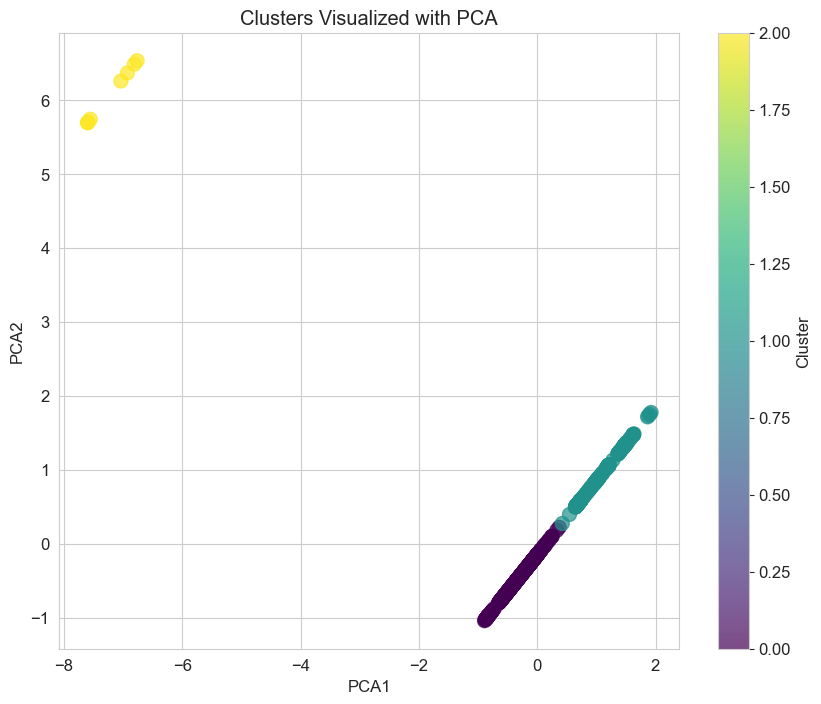

In [6]:
# Evaluation metrics
silhouette_avg = silhouette_score(X_scaled, clusters)
davies_bouldin_avg = davies_bouldin_score(X_scaled, clusters)

print(f"Silhouette Score: {silhouette_avg:.3f}")
print(f"Davies-Bouldin Index: {davies_bouldin_avg:.3f}")

# PCA visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
pca_df = pd.DataFrame(X_pca, columns=['PCA1', 'PCA2'])
pca_df['Cluster'] = clusters

plt.figure(figsize=(10, 8))
plt.scatter(pca_df['PCA1'], pca_df['PCA2'], c=pca_df['Cluster'], cmap='viridis', s=100, alpha=0.7)
plt.title('Clusters Visualized with PCA')
plt.xlabel('PCA1')
plt.ylabel('PCA2')
plt.colorbar(label='Cluster')
plt.savefig('figures/pca_clusters.png')
plt.show()


## 7. AI-Generated Analysis Reports
Automated generation of ethical reflection and summary reports based on clustering results.

In [7]:
# Import reporting utilities
from reporting_utils import generate_ethical_reflection, generate_summary_report, display_report_in_notebook

# Generate Ethical Reflection Report
print("\n" + "="*50)
print("🤖 AI-GENERATED ETHICAL REFLECTION REPORT")
print("="*50)

ethical_report = generate_ethical_reflection(df, features, silhouette_avg, optimal_k)
display_report_in_notebook(ethical_report, "Ethical Reflection Report")

# Generate Summary Report
print("\n" + "="*50)
print("🤖 AI-GENERATED SUMMARY REPORT")
print("="*50)

summary_report = generate_summary_report(df, features, optimal_k, silhouette_avg, davies_bouldin_avg)
display_report_in_notebook(summary_report, "Summary Report")



🤖 AI-GENERATED ETHICAL REFLECTION REPORT

========================= Ethical Reflection Report =========================


# Ethical Reflection: AI for Sustainable Cities (SDG 11)

## Data Bias
The UN DESA Population Division data contains **715 urban agglomerations** from approximately **87 countries**. Potential biases include:

### Current Analysis Concerns:
- **Data Completeness:** 2 numeric features used for clustering
- **Geographic Coverage:** Cities vary significantly in reporting quality and completeness
- **Temporal Challenges:** Analysis based on historical data may not capture recent trends
- **Over-simplification Risk:** K-Means clustering reduces complex urban systems into **3 discrete groups**

### Algorithmic Risks with Current Model:
- **Silhouette Score: 0.771** - Strong cluster separation
- **Misclassification Risk:** Cities near cluster boundaries may receive suboptimal interventions
- **Bias Propagation:** Statistical methods may amplify existing data collection disparities

## Fairness: Ensuring Developing Regions Are Not Misrepresented

### Current Clustering Challenges:
- **Representation Disparity:** Only 87 countries represented, may under-sample developing regions
- **False Precision:** Statistical scores don't account for local context and unique challenges
- **Equity Impact:** Clustering could lead to under-resourcing of underrepresented urban areas

## Sustainability Impact and Responsible AI Practices

### Recommendations for Current Implementation:
1. **Counter Bias:** Current Silhouette Score (0.771) indicates good separation, but continuous monitoring required
2. **Transparent Methodology:** Document all preprocessing and parameter choices
3. **Stakeholder Collaboration:** Involve local urban experts for cluster interpretation
4. **Continuous Updating:** Reassess clusters with new data to capture evolving trends
5. **Holistic Planning:** Use clustering as one of multiple tools for urban planning decisions

## Mitigation Strategies
- **Data Enrichment:** Supplement official statistics with alternative community-led sources
- **Algorithm Transparency:** Clear documentation of clustering methodology and limitations
- **Human Oversight:** Expert review of cluster interpretations before policy implementation
- **Global Capacity Building:** Support improved data collection in underrepresented regions



🤖 AI-GENERATED SUMMARY REPORT

============== Summary Report ==============


# Clustering Urban Indicators for SDG 11: Sustainable Cities and Communities

## SDG Addressed and Problem Statement
This project addresses **Sustainable Development Goal 11: Sustainable Cities and Communities** by analyzing global population data to identify urbanization patterns. The current analysis processed **715 urban agglomerations** using **2 features** and identified **3 distinct clusters**.

## ML Method Used
**K-Means Clustering** was applied with the following configuration:
- **Clusters Identified:** 3
- **Features Analyzed:** Index_agg, City Code
- **Data Preprocessing:** Standardization and missing value removal
- **Evaluation Metrics:**
  - Silhouette Score: 0.771
  - Davies-Bouldin Index: 0.274

## Main Findings and Visual Insights

### Clustering Results:
- **Number of Clusters:** 3
- **Silhouette Score:** 0.771 (Strong separation)
- **Cluster Distribution:**
  - Cluster 0: 504 cities (70.5%)
  - Cluster 1: 203 cities (28.4%)
  - Cluster 2: 8 cities (1.1%)


### Current Model Performance:
- **Excellent Clustering:** Silhouette Score (0.771) indicates very strong cluster cohesion and separation
- **Strong Cluster Separation:** Davies-Bouldin Index (0.274) indicates well-separated clusters


## Contribution to Sustainable Urban Planning

### Actionable Insights from Current Clustering:
1. **3 Urban Development Archetypes:** Cities grouped by similar sustainability challenges
2. **Targeted Interventions:** Resource allocation based on cluster characteristics
3. **Global Comparative Analysis:** Benchmarking across similar urban development stages
4. **SDG 11 Progress Tracking:** Evidence-based monitoring of sustainable urbanization goals

### Recommended Next Steps:
- Validate cluster interpretations with urban development experts
- Consider adjusting clustering parameters for improved separation
- Integrate with additional data sources for more comprehensive analysis
- Monitor cluster transitions over time with updated data

## 8. Save Outputs
Saving the clustered dataset.

In [8]:
# Create figures directory
import os
os.makedirs('figures', exist_ok=True)

# Save clustered dataset
df.to_csv('data/clustered_cities.csv', index=False)
print("Saved clustered data successfully!")


Saved clustered data successfully!
